# Decision Tree

#### Pedro Mauri Mtz - A01029143

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

### Data science

In [3]:
df = pd.read_csv(os.path.join(ROOT, "Datasets", "dataset_DT.csv"), sep=",")
df_copy = df.copy()
df.head()

,Result,Initial Payment,Last Payment,Credit Score,House Number
0,yes,201,10018,250,3046
1,yes,205,10016,395,3044
2,yes,257,10129,109,3251
3,yes,246,10064,324,3137
4,yes,117,10115,496,3094


In [4]:
df.isna().sum()

Result             0
Initial Payment    0
Last Payment       0
Credit Score       0
House Number       0
dtype: int64

In [5]:
df.nunique()

Result               2
Initial Payment    369
Last Payment       917
Credit Score       614
House Number       773
dtype: int64

In [6]:
X = df.drop("Result", axis = 1)
y = df["Result"]

In [7]:
X.shape, y.shape

((1000, 4), (1000,))

### Create datasets

In [8]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

### Decision Tree Classifier

In [9]:
# Create the Decision Tree Classifier model
DT_Model = DecisionTreeClassifier(criterion = "entropy", max_depth = 3, min_samples_split = 5)

#### Training

In [10]:
# Train the model
DT_Model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [11]:
y_pred_train_data = DT_Model.predict(x_train)
accuracy_train_data = accuracy_score(y_train, y_pred_train_data)
print(f"Model Accuracy on Training Data: {accuracy_train_data}")

Model Accuracy on Training Data: 0.92625


#### Testing

In [12]:
# Test the model
y_pred = DT_Model.predict(x_test)

In [13]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy}")

Model Accuracy: 0.93


In [14]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[99 10]
 [ 4 87]]


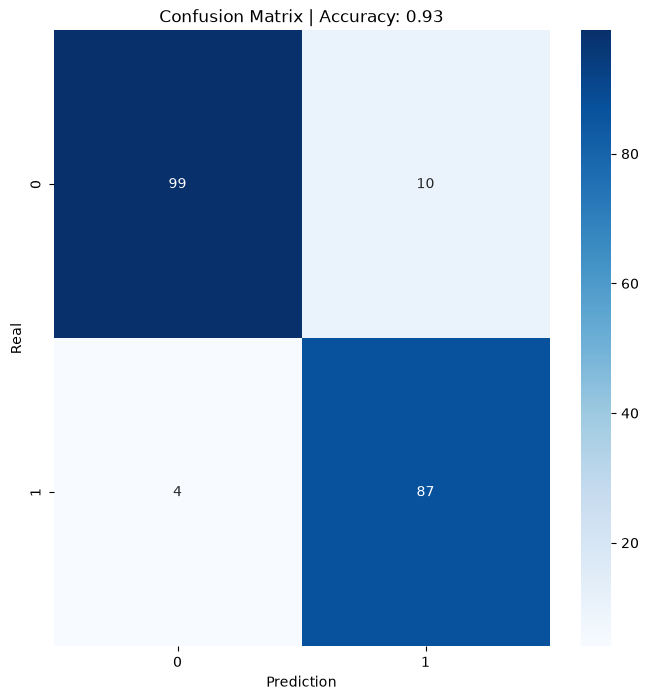

In [15]:
plt.figure(figsize = (8, 8))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues")
plt.ylabel("Real")
plt.xlabel("Prediction")
plt.title(f"Confusion Matrix | Accuracy: {accuracy}")
plt.show()